# Preprocessing - Hand Gesture Landmarks Dataset

This notebook prepares the raw `landmarks.csv` file (produced by `extract_landmarks.py`) for training.
Per project requirements, we work with the (x, y) landmark coordinates only — any `z` columns are
dropped, and no extra engineered features (distances/angles) are added.

1. Load the data
2. **Drop the z-coordinate** columns — keep x, y only
3. **Exploratory Data Analysis (EDA)** — class distribution, coordinate ranges, a sample hand plot
4. **Normalize** the landmarks (translation + scaling) and save `landmarks_normalized.csv`
5. Check for missing values / duplicates
6. Encode labels (digits 0-9 and letters A-Z) into numeric classes
7. Split into Train / Validation / Test sets (stratified)
8. **Augment the training set** with small rotations (still x, y only — more examples, no new features)
9. Save the final CSV files ready for training


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 10)


## 1. Load the data

In [2]:
CSV_PATH = r"D:\project\project_codolearn_final\landmarks_xyz.csv"  # change this if your file has a different name/path

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head()


Shape: (2966, 65)


,label,filename,x0,y0,z0,...,y19,z19,x20,y20,z20
0,0,hand1_0_bot_seg_1_cropped.jpeg,0.312942,0.397387,3.224581e-07,...,0.186058,-0.097161,0.653163,0.222400,-0.088176
1,0,hand1_0_bot_seg_2_cropped.jpeg,0.313096,0.252728,9.337390e-07,...,0.074784,-0.192277,0.642677,0.114115,-0.195118
2,0,hand1_0_bot_seg_4_cropped.jpeg,0.356116,0.301976,9.525323e-07,...,0.138402,-0.158360,0.732512,0.187434,-0.155310
3,0,hand1_0_bot_seg_5_cropped.jpeg,0.455835,0.640160,1.220114e-06,...,0.182092,-0.172910,0.625365,0.241355,-0.162631
4,0,hand1_0_dif_seg_1_cropped.jpeg,0.408416,0.813854,5.991583e-07,...,0.178700,-0.219718,0.742257,0.227759,-0.195721


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   label     2966 non-null   object 
 1   filename  2966 non-null   object 
 2   x0        2966 non-null   float64
 3   y0        2966 non-null   float64
 4   z0        2966 non-null   float64
 5   x1        2966 non-null   float64
 6   y1        2966 non-null   float64
 7   z1        2966 non-null   float64
 8   x2        2966 non-null   float64
 9   y2        2966 non-null   float64
 10  z2        2966 non-null   float64
 11  x3        2966 non-null   float64
 12  y3        2966 non-null   float64
 13  z3        2966 non-null   float64
 14  x4        2966 non-null   float64
 15  y4        2966 non-null   float64
 16  z4        2966 non-null   float64
 17  x5        2966 non-null   float64
 18  y5        2966 non-null   float64
 19  z5        2966 non-null   float64
 20  x6        2966 non-null   floa

## 2. Drop the Z-Coordinate — Keep (x, y) Only

If the landmarks were extracted with `z0...z20` columns as well, we drop them here so the rest of
the pipeline works on (x, y) only, as required.

In [4]:
z_cols = [c for c in df.columns if c.startswith("z") and c[1:].isdigit()]

if z_cols:
    df = df.drop(columns=z_cols)
    print(f"Dropped {len(z_cols)} z-coordinate columns: {z_cols}")
else:
    print("No z-coordinate columns found — data is already (x, y) only.")

print("Shape after dropping z columns:", df.shape)
df.head()


Dropped 21 z-coordinate columns: ['z0', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z20']
Shape after dropping z columns: (2966, 44)


,label,filename,x0,y0,x1,...,y18,x19,y19,x20,y20
0,0,hand1_0_bot_seg_1_cropped.jpeg,0.312942,0.397387,0.371085,...,0.145686,0.611703,0.186058,0.653163,0.222400
1,0,hand1_0_bot_seg_2_cropped.jpeg,0.313096,0.252728,0.343643,...,0.025339,0.594196,0.074784,0.642677,0.114115
2,0,hand1_0_bot_seg_4_cropped.jpeg,0.356116,0.301976,0.376485,...,0.077566,0.700639,0.138402,0.732512,0.187434
3,0,hand1_0_bot_seg_5_cropped.jpeg,0.455835,0.640160,0.591049,...,0.173296,0.545474,0.182092,0.625365,0.241355
4,0,hand1_0_dif_seg_1_cropped.jpeg,0.408416,0.813854,0.590270,...,0.185724,0.662430,0.178700,0.742257,0.227759


### 3.1 Class Distribution

label
0     42
1     65
2     55
3     70
4     70
5     70
6     58
7     66
8     65
9     70
A     73
B    108
C     93
D    112
E     76
F    111
G    102
H    100
I    102
J     68
K    111
L    110
M     61
N     61
O     84
P    100
Q     63
R     97
S     57
T     53
U    104
V    106
W    101
X     89
Y     93
Z    100
Name: count, dtype: int64


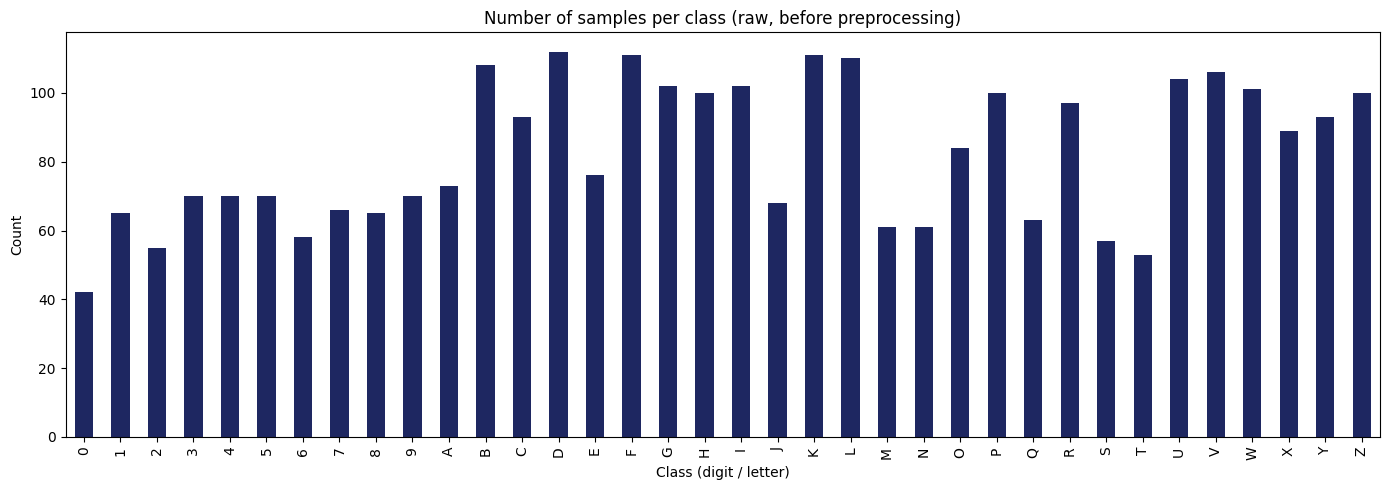


Min samples in a class: 42  (0)
Max samples in a class: 112  (D)


In [5]:
class_counts = df["label"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(14, 5))
class_counts.plot(kind="bar", color="#1E2761")
plt.title("Number of samples per class (raw, before preprocessing)")
plt.xlabel("Class (digit / letter)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"\nMin samples in a class: {class_counts.min()}  ({class_counts.idxmin()})")
print(f"Max samples in a class: {class_counts.max()}  ({class_counts.idxmax()})")


### 3.2 Coordinate Summary Statistics

In [6]:
coord_cols = [c for c in df.columns if c not in ("label", "filename")]
df[coord_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
x0,2966.0,0.463869,0.180876,-0.088456,0.362203,0.483282,0.540834,1.009458
y0,2966.0,0.768565,0.169745,0.031572,0.697733,0.827509,0.890016,1.019351
x1,2966.0,0.561991,0.170765,-0.062187,0.499213,0.608205,0.660560,0.955966
y1,2966.0,0.694856,0.148561,0.067938,0.622223,0.739655,0.806209,0.971300
x2,2966.0,0.600888,0.160690,0.017795,0.563668,0.651256,0.700750,0.947135
y2,2966.0,0.568975,0.125960,0.097350,0.499327,0.592449,0.651309,0.898639
x3,2966.0,0.568068,0.159664,0.010365,0.485850,0.584924,0.695782,0.943092
y3,2966.0,0.476632,0.131192,0.089361,0.402203,0.479277,0.549567,0.893794
x4,2966.0,0.515740,0.186041,-0.084395,0.394526,0.491503,0.626749,0.962898
y4,2966.0,0.436350,0.149091,0.044529,0.346983,0.434476,0.519244,0.953682


### 3.3 Outlier Check

A boxplot of all x/y coordinate columns. Raw MediaPipe coordinates are normally between 0 and 1
(relative to image width/height), so values far outside that range would flag a bad detection.

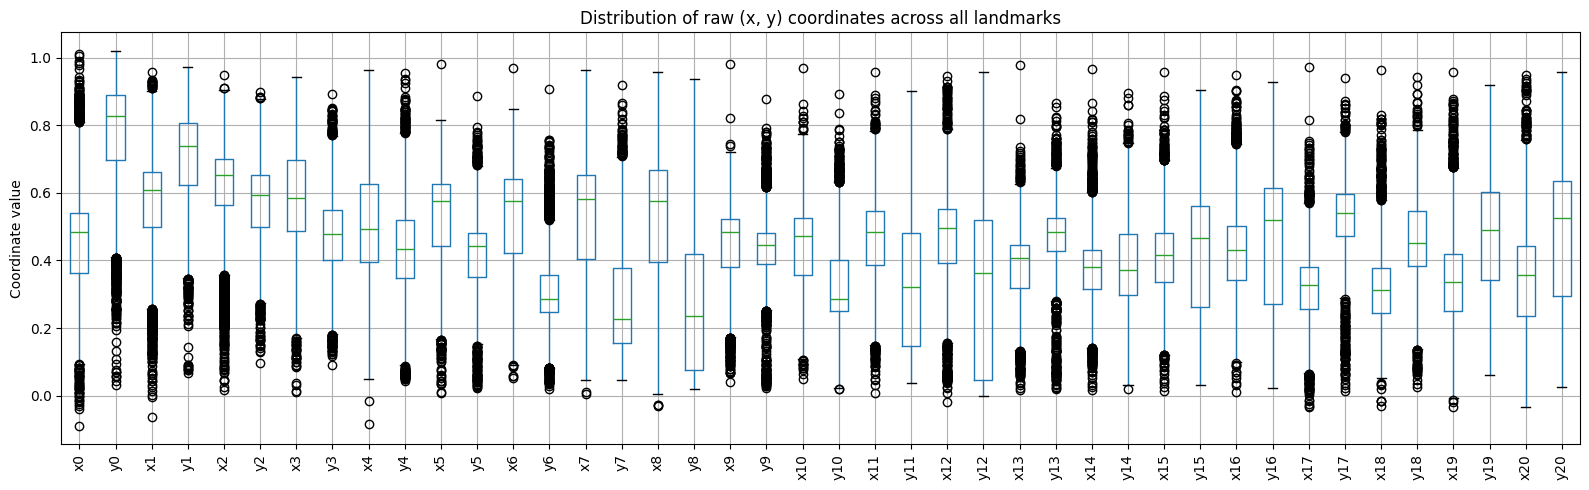

In [7]:
plt.figure(figsize=(16, 5))
df[coord_cols].boxplot(rot=90)
plt.title("Distribution of raw (x, y) coordinates across all landmarks")
plt.ylabel("Coordinate value")
plt.tight_layout()
plt.show()


### 3.4 Visualize a Sample Hand

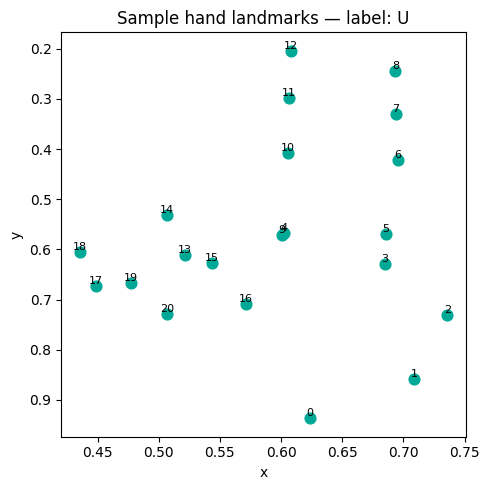

In [8]:
sample = df.sample(1, random_state=42).iloc[0]
num_landmarks = len(coord_cols) // 2

xs = [sample[f"x{i}"] for i in range(num_landmarks)]
ys = [sample[f"y{i}"] for i in range(num_landmarks)]

plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, c="#00A896", s=60, zorder=3)
for i, (x, y) in enumerate(zip(xs, ys)):
    plt.annotate(str(i), (x, y), fontsize=8, ha="center", va="bottom")
plt.gca().invert_yaxis()  # image coordinates: y grows downward
plt.title(f"Sample hand landmarks — label: {sample['label']}")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


### 3.5 Missing Values Overview

(Rows with missing values are actually dropped later in Section 5 — this is just a first look.)

In [9]:
missing_per_col = df.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0]

if len(missing_per_col) > 0:
    print("Columns with missing values:")
    print(missing_per_col)
else:
    print("No missing values found.")


No missing values found.


## 4. Normalization

The raw landmarks from MediaPipe are in absolute image coordinates (0 to 1, relative to image width/height),
so the same hand shape looks different depending on where the hand is in the frame and how close it is to the camera.

We normalize so the model learns hand **shape**, not position or size:

1. **Translation**: subtract the wrist (landmark 0) coordinates from every point, so the wrist becomes the origin (0, 0).
2. **Scaling**: divide every coordinate by the distance between the wrist (landmark 0) and the middle finger MCP joint
   (landmark 9), so hand size / distance from camera doesn't matter.


In [10]:
def normalize_row(row, num_landmarks=21):
    xs = np.array([row[f"x{i}"] for i in range(num_landmarks)], dtype=float)
    ys = np.array([row[f"y{i}"] for i in range(num_landmarks)], dtype=float)

    # Translation: wrist (landmark 0) becomes the origin
    wrist_x, wrist_y = xs[0], ys[0]
    xs = xs - wrist_x
    ys = ys - wrist_y

    # Scaling: distance from wrist to middle finger MCP (landmark 9)
    scale = np.sqrt(xs[9] ** 2 + ys[9] ** 2)
    if scale == 0:
        scale = 1e-6  # avoid division by zero on degenerate detections

    xs = xs / scale
    ys = ys / scale

    normalized = {}
    for i in range(num_landmarks):
        normalized[f"x{i}"] = xs[i]
        normalized[f"y{i}"] = ys[i]
    return pd.Series(normalized)


normalized_coords = df.apply(normalize_row, axis=1)

df_norm = df[["label", "filename"]].copy()
df_norm = pd.concat([df_norm, normalized_coords], axis=1)

df_norm.to_csv("landmarks_normalized.csv", index=False)
print("Saved landmarks_normalized.csv, shape:", df_norm.shape)
df_norm.head()


Saved landmarks_normalized.csv, shape: (2966, 44)


,label,filename,x0,y0,x1,...,y18,x19,y19,x20,y20
0,0,hand1_0_bot_seg_1_cropped.jpeg,0.0,0.0,0.163776,...,-0.708984,0.841542,-0.595266,0.958326,-0.492900
1,0,hand1_0_bot_seg_2_cropped.jpeg,0.0,0.0,0.153496,...,-1.142632,1.412528,-0.894173,1.656147,-0.696533
2,0,hand1_0_bot_seg_4_cropped.jpeg,0.0,0.0,0.076378,...,-0.841499,1.291902,-0.613374,1.411422,-0.429515
3,0,hand1_0_bot_seg_5_cropped.jpeg,0.0,0.0,0.337043,...,-1.163732,0.223439,-1.141806,0.422581,-0.994083
4,0,hand1_0_dif_seg_1_cropped.jpeg,0.0,0.0,0.374209,...,-1.292531,0.522696,-1.306984,0.686961,-1.206035


From this point on, we continue working with `df_norm` (the normalized version) instead of the raw `df`.

In [11]:
df = df_norm.copy()


## 5. Missing values & duplicates

In [12]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

duplicate_rows = df.duplicated(subset=df.columns.difference(["filename"])).sum()
print(f"Duplicate feature rows (same landmarks, ignoring filename): {duplicate_rows}")

# Drop rows with missing values, if any
df = df.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df.shape)


Missing values per column:
0 total missing values
Duplicate feature rows (same landmarks, ignoring filename): 1
Shape after dropping missing values: (2966, 44)


## 6. Label encoding

In [13]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

# Mapping reference: class name -> encoded number
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:")
for k, v in label_mapping.items():
    print(f"  {k} -> {v}")


Label mapping:
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3
  4 -> 4
  5 -> 5
  6 -> 6
  7 -> 7
  8 -> 8
  9 -> 9
  A -> 10
  B -> 11
  C -> 12
  D -> 13
  E -> 14
  F -> 15
  G -> 16
  H -> 17
  I -> 18
  J -> 19
  K -> 20
  L -> 21
  M -> 22
  N -> 23
  O -> 24
  P -> 25
  Q -> 26
  R -> 27
  S -> 28
  T -> 29
  U -> 30
  V -> 31
  W -> 32
  X -> 33
  Y -> 34
  Z -> 35


In [14]:
import json

with open("label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({str(k): int(v) for k, v in label_mapping.items()}, f, ensure_ascii=False, indent=2)

print("Saved label_mapping.json (you'll need this later to decode predictions)")


Saved label_mapping.json (you'll need this later to decode predictions)


## 7. Separate features (X) and target (y)

In [15]:
feature_columns = [c for c in df.columns if c not in ("label", "filename", "label_encoded")]
print(f"Number of feature columns: {len(feature_columns)}")

X = df[feature_columns]
y = df["label_encoded"]


Number of feature columns: 42


## 8. Train / Validation / Test split

Using a stratified split so every class keeps roughly the same proportion in each set.
Default ratio: 70% train / 15% validation / 15% test.

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (2076, 42)  Val: (445, 42)  Test: (445, 42)


## 9. Data Augmentation (Training Set Only) — Small Rotations

We keep the feature set exactly as-is (x, y coordinates only — no new feature types). To help the
model generalize better and push accuracy higher, we generate extra **training** examples by
rotating each hand's landmarks slightly around the wrist (which is always the origin (0, 0) after
normalization).

This only adds more rows to the training data — it does **not** add any new columns/features, and it
is applied to the training set only. The validation and test sets stay untouched, so evaluation
remains fair.

In [17]:
def rotate_landmarks(X, angle_degrees):
    """Rotates all (x, y) landmark pairs around the origin (the wrist, always at 0,0
    after normalization) by the given angle. Returns a new DataFrame with the same columns."""
    theta = np.radians(angle_degrees)
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    X_rot = X.copy()
    n_landmarks = X.shape[1] // 2  # e.g. 21 landmarks -> 42 columns

    for i in range(n_landmarks):
        x_col, y_col = f"x{i}", f"y{i}"
        if x_col in X.columns and y_col in X.columns:
            x_vals, y_vals = X[x_col].values, X[y_col].values
            X_rot[x_col] = x_vals * cos_t - y_vals * sin_t
            X_rot[y_col] = x_vals * sin_t + y_vals * cos_t

    return X_rot


# Generate rotated copies of the TRAINING set only (never touch X_val / X_test)
angles = [-15, -10, -5, 5, 10, 15]

X_train_parts = [X_train]
y_train_parts = [y_train]

for angle in angles:
    X_train_parts.append(rotate_landmarks(X_train, angle))
    y_train_parts.append(y_train)

X_train_aug = pd.concat(X_train_parts, ignore_index=True)
y_train_aug = pd.concat(y_train_parts, ignore_index=True)

print(f"Original training samples: {len(X_train)}")
print(f"Augmented training samples: {len(X_train_aug)}  ({len(angles)} rotations x original + original)")


Original training samples: 2076
Augmented training samples: 14532  (6 rotations x original + original)


## 10. Save the final CSV files

In [18]:
# Original (non-augmented) splits
train_df = X_train.copy()
train_df["label"] = y_train.values

val_df = X_val.copy()
val_df["label"] = y_val.values

test_df = X_test.copy()
test_df["label"] = y_test.values

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

# Augmented training set (use this one for model training)
train_aug_df = X_train_aug.copy()
train_aug_df["label"] = y_train_aug.values
train_aug_df.to_csv("train_augmented.csv", index=False)

print("Saved: train.csv, val.csv, test.csv")
print("Saved: train_augmented.csv  <-- use this for training")


Saved: train.csv, val.csv, test.csv
Saved: train_augmented.csv  <-- use this for training


## Done ✅

You now have:
- `landmarks_normalized.csv` — the normalized landmarks (wrist-centered, scale-independent, x/y only)
- `train.csv`, `val.csv`, `test.csv` — the original stratified splits (x, y only)
- `train_augmented.csv` — the training set with added rotated copies (use this to fit your models;
  always evaluate on the untouched `val.csv` / `test.csv`)
- `label_mapping.json` — to decode the numeric predictions back into digits/letters

Notes:
- If class balance looked uneven in the EDA step, consider adding `class_weight="balanced"` (sklearn
  models) or collecting a few more images for the underrepresented classes.
- All features are the original (x, y) coordinates only — z was dropped, and no distances or angles
  were added.
